In [1]:
import numpy as np
from pathlib import Path
import os, sys
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import json
from scipy.stats import wasserstein_distance

repo_root = Path("/home/thardy/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder")
os.chdir(repo_root)

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.environ["PYTHONPATH"] = str(repo_root) + os.pathsep + os.environ.get("PYTHONPATH", "")

import LEAD as lead


# Important variables
cwd = Path.cwd()
SNRs = np.array([-np.inf,-13,-11,-9,-7,-5,-3])
SubIDs = ['01','02','03','05','06','07','08','09','11','12','13','14','15','17','19','20','22','23','24','25']
colormap = {0: (0, 0, 0), 1: (0, 0.25, 1), 2: (0, 0.9375, 1), 3: (0, 0.91, 0.1), 4: (1, 0.6, 0), 5: (1, 0, 0), 6: (0.8, 0, 0.8)}

# Publication-quality plotting defaults
plt.rcParams['figure.dpi'] = 200
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.05

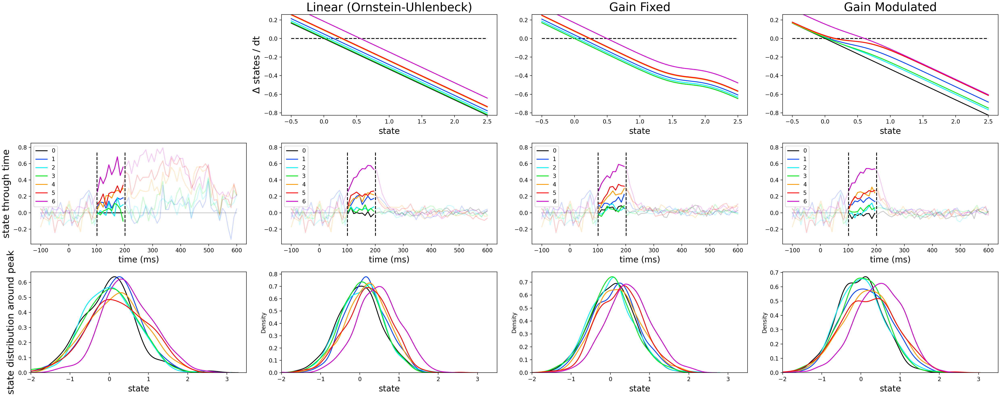

In [2]:
task = 'Passive'
file_path = f'Fit_{task}_early'
# os.makedirs(file_path, exist_ok=True)
    
for part in [18]: # tqdm(range(20)):
    
    # Load data
    data_ref = f'myEpochs_{task}/Epoch_{SubIDs[part]}-epo.fif'
    epochs_file = cwd.parents[0] / data_ref
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        state_train = lead.STG(epochs_file, tmin=100, tmax=200)
        n_categories = len(list(state_train.keys()))
        categories = list(range(n_categories))

    # Input definition (same for all categories & trials)
    one_input = np.concatenate((np.zeros(60), np.ones(10)))
    input_train = {cat: np.stack([one_input for _ in range(state_train[cat].shape[0])]) for cat in categories}

    # Re-organize to gather baseline windows together (= whole trials with no stim + baseline of trials with a stim)
    no_stim_sliced = np.concatenate([state_train[0][:, i*50:(i+1)*50] for i in range(5)])
    pre_stim_sliced = np.concatenate([state_train[cat][:, :50] for cat in range(1, n_categories)])
    state_train[0] = np.concatenate((no_stim_sliced, pre_stim_sliced))
    input_train[0] = np.zeros_like(state_train[0])
    
    # ---- Fit StratifiedLinear ----
    # linear = lead.fitting_tools.clever_fit_linear(state_train = state_train, input_train = input_train, input_start_index=60, input_stop_index=70)
    # linear.save_params(f'{file_path}/LinearModel_part{part}_params')
    linear = lead.model.StratifiedLinear(tau=10, process_noise=0.1, measure_noise=0.1, w0=0)
    linear.load_params(f'{file_path}/LinearModel_part{part}_params')

    # ---- Fit StratifiedGainModul  ----
    # gainmodul = lead.fitting_tools.clever_fit_gainmodul(linear_prefitted = linear, state_train = state_train, input_train = input_train, n_loops = 2, input_start_index=60, input_stop_index=70)
    # gainmodul.save_params(f'{file_path}/GainModulatedModel_part{part}_params')
    gainmodul = lead.model.StratifiedGainModulation(tau=10, process_noise=0.1, measure_noise=0.1, threshold=1, sharpness=5)
    gainmodul.load_params(f'{file_path}/GainModulatedModel_part{part}_params')

    # ---- Fit StratifiedNonLinear1  ----
    # nonlinear = lead.fitting_tools.clever_fit_nonlinear1(linear_prefitted = linear, state_train = state_train, input_train = input_train, n_loops = 2, input_start_index=60, input_stop_index=70)
    # nonlinear.save_params(f'{file_path}/GainFixedModel_part{part}_params')
    nonlinear = lead.model.StratifiedNonLinear1(tau=10, process_noise=0.1, measure_noise=0.1, threshold=1, sharpness=5, gain=0.1)
    nonlinear.load_params(f'{file_path}/GainFixedModel_part{part}_params')

    # ---- Run Simulations from the fitted models  ----
    n_trials = 500
    one_input = np.concatenate((np.zeros(60), np.ones(10), np.zeros(130)))
    input_series = {cat: np.stack([one_input for _ in range(n_trials)]) for cat in categories}
    measures_linear = linear.measure_simulations(input_series = input_series)
    measures_nonlinear = nonlinear.measure_simulations(input_series = input_series)
    measures_gainmodul = gainmodul.measure_simulations(input_series = input_series)
    

    # ---- Plot Results  ----
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        state_train = lead.STG(epochs_file, tmin=100, tmax=200)
        state_train = {cat: state_train[cat][:,:110] for cat in categories}
    one_input = np.concatenate((np.zeros(60), np.ones(10)))
    input_train = {cat: np.stack([one_input for _ in range(state_train[cat].shape[0])]) for cat in categories}

    # ---- Run Simulations from the fitted models  ----
    one_input = np.concatenate((np.ones(10), np.zeros(40))) # np.concatenate((np.zeros(60), np.ones(10), np.zeros(130)))
    input_series = {cat: np.stack([one_input for _ in range(5*state_train[cat].shape[0])]) for cat in categories}
    simulations_linear = linear.measure_simulations(input_series = input_series, initial_states = {cat: np.repeat(state_train[cat][:, 60].flatten(), 5) for cat in categories})
    measures_linear = {cat: np.concatenate((np.repeat(state_train[cat][:, :60], 5, axis=0), simulations_linear[cat]), axis=1) for cat in categories}
    simulations_nonlinear = nonlinear.measure_simulations(input_series = input_series, initial_states = {cat: np.repeat(state_train[cat][:, 60].flatten(), 5) for cat in categories})
    measures_nonlinear = {cat: np.concatenate((np.repeat(state_train[cat][:, :60], 5, axis=0), simulations_nonlinear[cat]), axis=1) for cat in categories}
    simulations_gainmodul = gainmodul.measure_simulations(input_series = input_series, initial_states = {cat: np.repeat(state_train[cat][:, 60].flatten(), 5) for cat in categories})
    measures_gainmodul = {cat: np.concatenate((np.repeat(state_train[cat][:, :60], 5, axis=0), simulations_gainmodul[cat]), axis=1) for cat in categories}

    
    states = np.linspace(-0.5,2.5,150)
    conditions = [(0, 0), (1, 1), (1,2), (1,3), (1,4), (1,5)]
    if n_categories > len(conditions):
        conditions.append((1,6))
    labels = {cat: str(cat) for cat in range(n_categories)}
    
    plt.figure(figsize=(25, 10), dpi=200)
    
    # Define models and their corresponding measures
    models = [
        ("Linear (Ornstein-Uhlenbeck)", linear.core, measures_linear),
        ("Gain Fixed", nonlinear.core, measures_nonlinear),
        ("Gain Modulated", gainmodul.core, measures_gainmodul)
    ]
    
    
    # === TOP ROW: Δstate/dt plots ===
    for i, (title, model_func, _) in enumerate(models, start=1):
        plt.subplot2grid((9, 4), (0, i), rowspan=3)
        plt.plot([states[0], states[-1]], [0, 0], linestyle='--', color='black')
    
        for cond_ind, (input_value, signal_category) in enumerate(conditions):
            plt.plot(
                states,
                model_func(states, input_value * np.ones_like(states), signal_category) - states,
                color=colormap[cond_ind],
                label=labels[cond_ind]
            )
    
        plt.xlabel('state', fontsize=15)
        if i == 1:
            plt.ylabel(r'$\Delta$ states / dt', fontsize=17)
        plt.ylim(linear.core(np.array([2.5]), np.array([0]), 0) - 2.5, linear.core(np.array([-0.5]), np.array([1]), 5) + 0.5)
        plt.title(title, fontsize=21)
    
    # === MIDDLE ROW: Time-series plots ===
    # Define all time-series datasets
    time_series_data = [
        ("Real Participant", state_train),
        ("Linear", measures_linear),
        ("Non-Linear", measures_nonlinear),
        ("Gain Modulation", measures_gainmodul)
    ]
    times = np.linspace(-100, 600, 70)
    
    for i, (title, data_dict) in enumerate(time_series_data):
        plt.subplot2grid((9, 4), (3, i), rowspan=3)
    
        for cat in categories:
            mean_trace = data_dict[cat][:, 40:110].mean(0)
            # plt.plot(times, mean_trace, color=colormap[cat], label=str(cat))
            plt.plot(times[:21], mean_trace[:21], color=colormap[cat], alpha=0.2)
            plt.plot(times[20:30], mean_trace[20:30], color=colormap[cat], label=str(cat))
            plt.plot(times[29:70], mean_trace[29:70], color=colormap[cat], alpha=0.2)
    
        if title == "Real Participant":
            ymin, ymax = plt.ylim()
        else:
            plt.ylim(ymin, ymax)
        plt.plot([101, 101], [ymin+0.1, ymax-0.1], color='black', linestyle='--')
        plt.plot([201, 201], [ymin+0.1, ymax-0.1], color='black', linestyle='--')
        # plt.plot(times, ymax * one_input / 4, color='black', linestyle=':', label='input')
    
        plt.xlabel('time (ms)', fontsize=15)
        if i == 0:
            plt.ylabel('state through time', fontsize=17)
        # plt.title(title, fontsize=15)
        plt.legend(loc='upper left')
    
    # === BOTTOM ROW: KDE distributions ===
    t1, t2 = 60, 70
    xmin, xmax = -2, 3.5
    distribution_data = [
        ("Real Participant", state_train),
        ("Linear", measures_linear),
        ("Non-Linear", measures_nonlinear),
        ("Gain Modulation", measures_gainmodul)
    ]
    
    for i, (title, data_dict) in enumerate(distribution_data):
        plt.subplot2grid((9, 4), (6, i), rowspan=3)
    
        avgs = {cat: np.mean(data_dict[cat][:, t1:t2], -1).flatten() for cat in categories}
        for cat in categories:
            sns.kdeplot(data=avgs[cat], label=str(cat), color=colormap[cat])
    
        plt.xlim(xmin, xmax)
        plt.xlabel('state', fontsize=15)
        if i == 0:
            plt.ylabel('state distribution around peak', fontsize=17)
        # plt.title(title, fontsize=15)
    
    plt.tight_layout()
    plt.savefig(f'{file_path}/AllModels_part{part}.png', dpi=600, bbox_inches='tight', pad_inches=0.05)
    # plt.savefig(f'{file_path}/AllModels_part{part}.pdf', bbox_inches='tight', pad_inches=0.05)
    plt.show()

  0%|          | 0/20 [00:00<?, ?it/s]

--- participant 0 (01), window [60:70] ---
  Linear (Ornstein-Uhlenbeck)    mean W = 0.114   (per SNR: 0.078, 0.087, 0.141, 0.120, 0.163, 0.095)
  Gain Fixed                     mean W = 0.108   (per SNR: 0.094, 0.058, 0.121, 0.116, 0.183, 0.078)
  Gain Modulated                 mean W = 0.078   (per SNR: 0.083, 0.069, 0.105, 0.082, 0.066, 0.060)


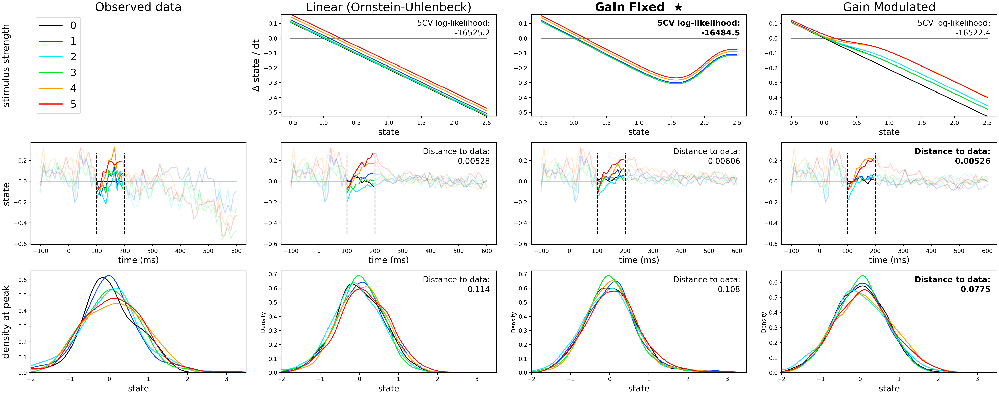

--- participant 1 (02), window [60:70] ---
  Linear (Ornstein-Uhlenbeck)    mean W = 0.089   (per SNR: 0.064, 0.054, 0.082, 0.180, 0.099, 0.055)
  Gain Fixed                     mean W = 0.080   (per SNR: 0.051, 0.067, 0.063, 0.152, 0.079, 0.067)
  Gain Modulated                 mean W = 0.065   (per SNR: 0.048, 0.062, 0.044, 0.095, 0.097, 0.046)


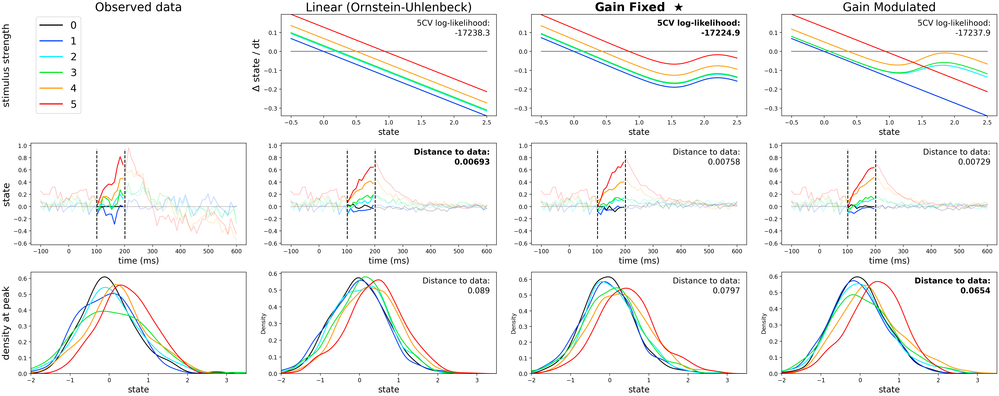

--- participant 2 (03), window [60:70] ---
  Linear (Ornstein-Uhlenbeck)    mean W = 0.121   (per SNR: 0.106, 0.137, 0.104, 0.132, 0.139, 0.106)
  Gain Fixed                     mean W = 0.102   (per SNR: 0.092, 0.110, 0.120, 0.095, 0.111, 0.082)
  Gain Modulated                 mean W = 0.087   (per SNR: 0.074, 0.149, 0.101, 0.060, 0.087, 0.050)


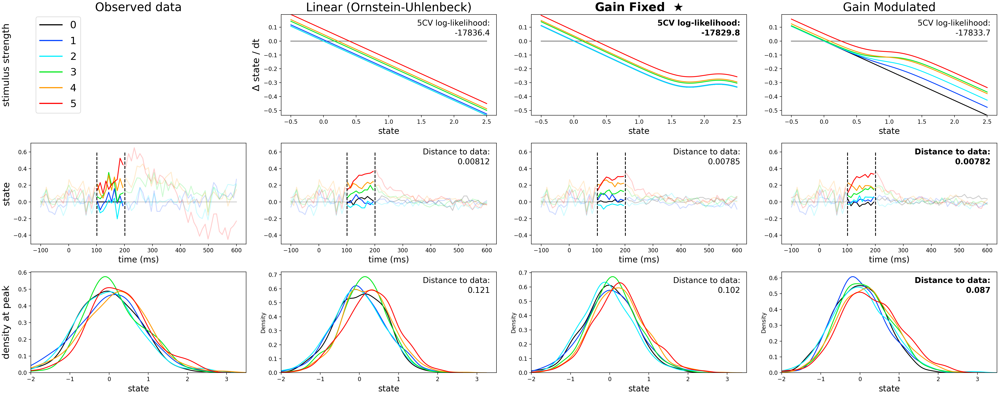

--- participant 3 (05), window [60:70] ---
  Linear (Ornstein-Uhlenbeck)    mean W = 0.089   (per SNR: 0.092, 0.080, 0.136, 0.064, 0.110, 0.051)
  Gain Fixed                     mean W = 0.097   (per SNR: 0.092, 0.076, 0.160, 0.079, 0.105, 0.068)
  Gain Modulated                 mean W = 0.097   (per SNR: 0.101, 0.082, 0.150, 0.067, 0.100, 0.084)


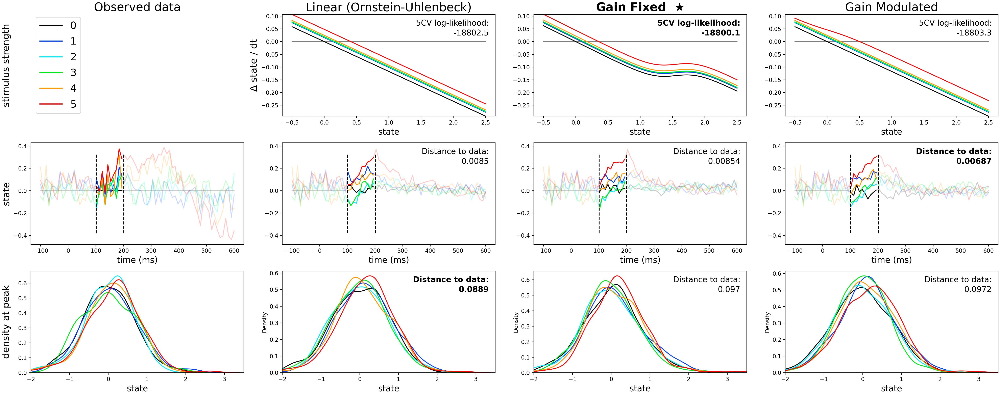

--- participant 4 (06), window [60:70] ---
  Linear (Ornstein-Uhlenbeck)    mean W = 0.076   (per SNR: 0.043, 0.083, 0.104, 0.076, 0.070, 0.081)
  Gain Fixed                     mean W = 0.073   (per SNR: 0.062, 0.093, 0.098, 0.058, 0.058, 0.070)
  Gain Modulated                 mean W = 0.079   (per SNR: 0.036, 0.091, 0.120, 0.071, 0.077, 0.078)


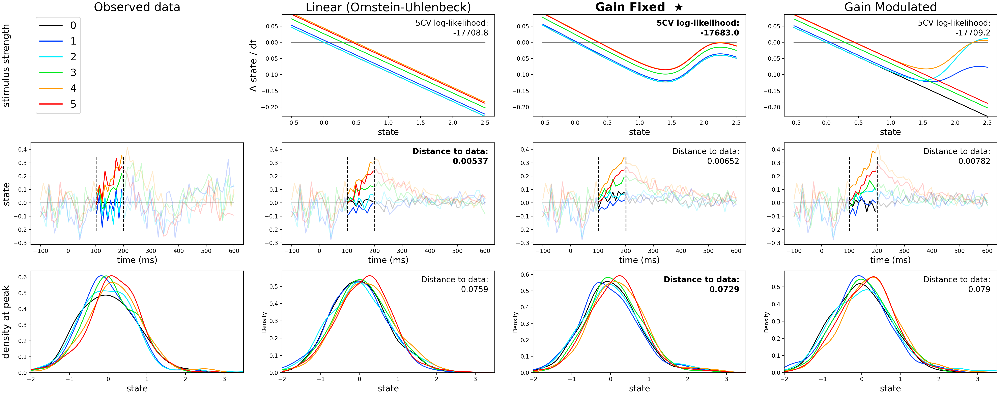

--- participant 5 (07), window [60:70] ---
  Linear (Ornstein-Uhlenbeck)    mean W = 0.080   (per SNR: 0.086, 0.070, 0.070, 0.080, 0.104, 0.067)
  Gain Fixed                     mean W = 0.087   (per SNR: 0.079, 0.079, 0.089, 0.092, 0.116, 0.069)
  Gain Modulated                 mean W = 0.071   (per SNR: 0.093, 0.079, 0.056, 0.079, 0.053, 0.066)


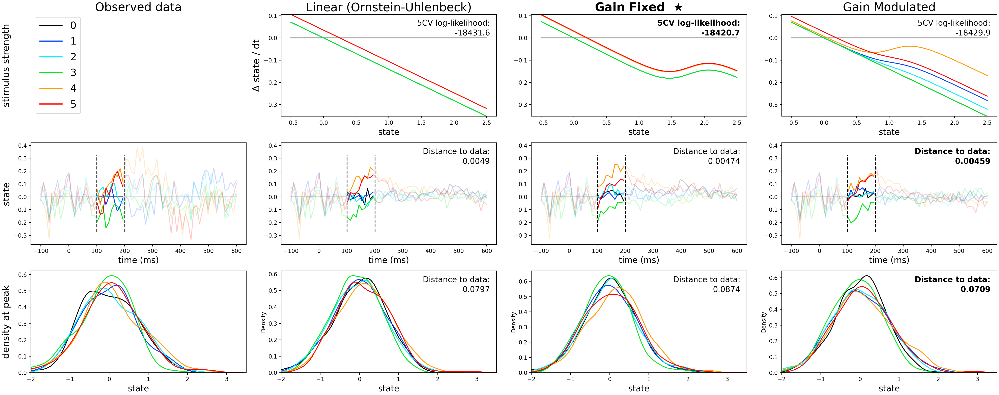

--- participant 6 (08), window [60:70] ---
  Linear (Ornstein-Uhlenbeck)    mean W = 0.109   (per SNR: 0.084, 0.088, 0.067, 0.105, 0.132, 0.178)
  Gain Fixed                     mean W = 0.110   (per SNR: 0.087, 0.096, 0.092, 0.089, 0.137, 0.156)
  Gain Modulated                 mean W = 0.088   (per SNR: 0.086, 0.111, 0.083, 0.075, 0.095, 0.079)


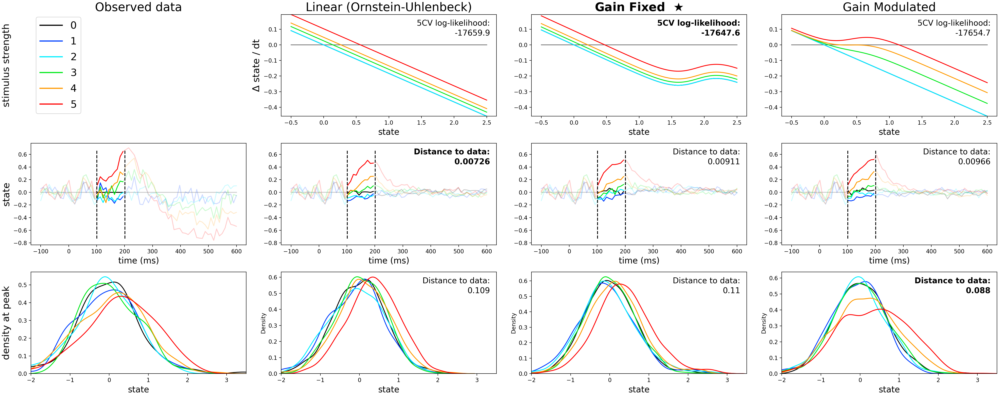

--- participant 7 (09), window [60:70] ---
  Linear (Ornstein-Uhlenbeck)    mean W = 0.079   (per SNR: 0.079, 0.066, 0.042, 0.071, 0.062, 0.152)
  Gain Fixed                     mean W = 0.081   (per SNR: 0.078, 0.087, 0.055, 0.082, 0.061, 0.121)
  Gain Modulated                 mean W = 0.063   (per SNR: 0.070, 0.088, 0.039, 0.048, 0.056, 0.079)


In [ ]:
for task in ['Active', 'Passive']:
    file_path = f'Fit_{task}_early'
    np.random.seed(42)

    # prepare for saving the secondary comparison metrics
    model_comparison_wasserstein = {}
    model_comparison_mse = {}

    # ---- 5CV log-likelihoods to annotate on the top row --------------------------
    json_path = cwd / f"5CV_{task}_early.json"
    with open(json_path, "r") as f:
        data_5cv = json.load(f)
        results_cv = data_5cv.get("results_cv")
        detailed = data_5cv['detailed']
    linear_ll, nonlinear_ll, gainmodul_ll = [], [], []
    for detail in detailed:
        linear_ll.append(detail['ll_linear_mean'])
        nonlinear_ll.append(detail['ll_nonlinear_mean'])
        gainmodul_ll.append(detail['ll_gainmod_mean'])
    CV_LOGLIK = {part: {"Linear": linear_ll[part], "GainFixed": nonlinear_ll[part], "GainModulated": gainmodul_ll[part]} for part in range(20)}

    def get_cv_loglik(part, model_key):
        """Return the 5CV log-likelihood for (participant, model), or nan if missing."""
        entry = CV_LOGLIK.get(part)
        return entry.get(model_key, np.nan)

    def fmt_score(value, decimals=1):
        """Format a score for display; blank-ish placeholder when not filled in yet."""
        if value is None or (isinstance(value, float) and np.isnan(value)):
            return "--"
        return f"{value:.{decimals}f}"

    # ---- Window used for the state distributions (bottom row) --------------------
    # Same window is used for the KDEs and for the Wasserstein distances, so the
    # printed number describes exactly the curves shown underneath it.
    t1, t2 = 60, 70

    def window_avgs(data_dict, categories, t1=t1, t2=t2):
        """Per-category trial-wise average state over the [t1, t2) window."""
        return {cat: np.mean(data_dict[cat][:, t1:t2], -1).flatten() for cat in categories}

    def mean_wasserstein(model_avgs, data_avgs, categories):
        """Mean over SNR categories of the 1D Wasserstein distance model vs data.

        Averaging per-SNR (rather than pooling all SNRs together) keeps the metric
        sensitive to a model that reproduces the marginal spread but misorders the
        SNR-conditional distributions.
        """
        dists = [wasserstein_distance(data_avgs[cat], model_avgs[cat]) for cat in categories]
        return float(np.mean(dists)), dists

    def mean_mse(model_measures, data_dict, categories, t1=t1, t2=t2):  # CHECK THE GOOD T1 AND T2 VALUES FOR EARLY BEFORE RUNNING IT
        """Mean over SNR categories of the MSE between the model's and the data's
        trial-averaged time-series, over the same [t1, t2) window shown in row 2."""
        mses = [np.mean((model_measures[cat][:, t1:t2].mean(0)
                        - data_dict[cat][:, t1:t2].mean(0)) ** 2)
                for cat in categories]
        return float(np.mean(mses)), mses


    for part in tqdm(range(20)):

        best_model = results_cv[part]

        # Load data
        data_ref = f'myEpochs_{task}/Epoch_{SubIDs[part]}-epo.fif'
        epochs_file = cwd.parents[0] / data_ref
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            state_train = lead.STG(epochs_file, tmin=100, tmax=200)
            n_categories = len(list(state_train.keys()))
            categories = list(range(n_categories))

        # Input definition (same for all categories & trials)
        one_input = np.concatenate((np.zeros(60), np.ones(10)))
        input_train = {cat: np.stack([one_input for _ in range(state_train[cat].shape[0])]) for cat in categories}

        # Re-organize to gather baseline windows together (= whole trials with no stim + baseline of trials with a stim)
        no_stim_sliced = np.concatenate([state_train[0][:, i*50:(i+1)*50] for i in range(5)])
        pre_stim_sliced = np.concatenate([state_train[cat][:, :50] for cat in range(1, n_categories)])
        state_train[0] = np.concatenate((no_stim_sliced, pre_stim_sliced))
        input_train[0] = np.zeros_like(state_train[0])

        # ---- Fit StratifiedLinear ----
        # linear = lead.fitting_tools.clever_fit_linear(state_train = state_train, input_train = input_train, input_start_index=75, input_stop_index=100)
        # linear.save_params(f'{file_path}/LinearModel_part{part}_params')
        linear = lead.model.StratifiedLinear(tau=10, process_noise=0.1, measure_noise=0.1, w0=0)
        linear.load_params(f'{file_path}/LinearModel_part{part}_params')

        # ---- Fit StratifiedGainModul  ----
        # gainmodul = lead.fitting_tools.clever_fit_gainmodul(linear_prefitted = linear, state_train = state_train, input_train = input_train, n_loops = 2, input_start_index=75, input_stop_index=100)
        # gainmodul.save_params(f'{file_path}/GainModulatedModel_part{part}_params')
        gainmodul = lead.model.StratifiedGainModulation(tau=10, process_noise=0.1, measure_noise=0.1, threshold=1, sharpness=5)
        gainmodul.load_params(f'{file_path}/GainModulatedModel_part{part}_params')

        # ---- Fit StratifiedNonLinear1  ----
        # nonlinear = lead.fitting_tools.clever_fit_nonlinear1(linear_prefitted = linear, state_train = state_train, input_train = input_train, n_loops = 2, input_start_index=75, input_stop_index=100)
        # nonlinear.save_params(f'{file_path}/GainFixedModel_part{part}_params')
        nonlinear = lead.model.StratifiedNonLinear1(tau=10, process_noise=0.1, measure_noise=0.1, threshold=1, sharpness=5, gain=0.1)
        nonlinear.load_params(f'{file_path}/GainFixedModel_part{part}_params')


        # ---- Plot Results  ----
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            state_train = lead.STG(epochs_file, tmin=100, tmax=200)
            state_train = {cat: state_train[cat][:,:110] for cat in categories}
        one_input = np.concatenate((np.zeros(60), np.ones(10)))
        input_train = {cat: np.stack([one_input for _ in range(state_train[cat].shape[0])]) for cat in categories}

        # ---- Run Simulations from the fitted models  ----
        one_input = np.concatenate((np.ones(10), np.zeros(40))) # np.concatenate((np.zeros(60), np.ones(10), np.zeros(130)))
        input_series = {cat: np.stack([one_input for _ in range(5*state_train[cat].shape[0])]) for cat in categories}
        simulations_linear = linear.measure_simulations(input_series = input_series, initial_states = {cat: np.repeat(state_train[cat][:, 60].flatten(), 5) for cat in categories})
        measures_linear = {cat: np.concatenate((np.repeat(state_train[cat][:, :60], 5, axis=0), simulations_linear[cat]), axis=1) for cat in categories}
        simulations_nonlinear = nonlinear.measure_simulations(input_series = input_series, initial_states = {cat: np.repeat(state_train[cat][:, 60].flatten(), 5) for cat in categories})
        measures_nonlinear = {cat: np.concatenate((np.repeat(state_train[cat][:, :60], 5, axis=0), simulations_nonlinear[cat]), axis=1) for cat in categories}
        simulations_gainmodul = gainmodul.measure_simulations(input_series = input_series, initial_states = {cat: np.repeat(state_train[cat][:, 60].flatten(), 5) for cat in categories})
        measures_gainmodul = {cat: np.concatenate((np.repeat(state_train[cat][:, :60], 5, axis=0), simulations_gainmodul[cat]), axis=1) for cat in categories}


        states = np.linspace(-0.5,2.5,150)
        conditions = [(0, 0), (1, 1), (1,2), (1,3), (1,4), (1,5)]
        if n_categories > len(conditions):
            conditions.append((1,6))
        labels = {cat: str(cat) for cat in range(n_categories)}

        # === Model registry ======================================================
        # key             -> used to look up the 5CV score and the winner
        # display_title   -> printed above the column
        MODEL_KEY_FROM_5CV = {"Linear": "Linear", "NonLinear1": "GainFixed", "GainModulation": "GainModulated"}
        best_key = MODEL_KEY_FROM_5CV.get(best_model, None)

        models = [
            dict(key="Linear",        title="Linear (Ornstein-Uhlenbeck)", core=linear.core,     measures=measures_linear),
            dict(key="GainFixed",     title="Gain Fixed",                  core=nonlinear.core, measures=measures_nonlinear),
            dict(key="GainModulated", title="Gain Modulated",              core=gainmodul.core, measures=measures_gainmodul),
        ]
        for m in models:
            m["is_best"] = (m["key"] == best_key)

        # === Wasserstein distances: model distributions vs observed ==============
        data_avgs = window_avgs(state_train, categories)
        for m in models:
            m["avgs"] = window_avgs(m["measures"], categories)
            m["wasserstein"], m["wasserstein_per_snr"] = mean_wasserstein(m["avgs"], data_avgs, categories)
            m["mse"], m["mse_per_snr"] = mean_mse(m["measures"], state_train, categories)

        print(f"--- participant {part} ({SubIDs[part]}), window [{t1}:{t2}] ---")
        for m in models:
            per_snr = ", ".join(f"{d:.3f}" for d in m["wasserstein_per_snr"])
            print(f"  {m['title']:<30s} mean W = {m['wasserstein']:.3f}   (per SNR: {per_snr})")

        # === Compute best metrics across models for bold formatting ===============
        valid_cvs = [get_cv_loglik(part, m["key"]) for m in models if not np.isnan(get_cv_loglik(part, m["key"]))]
        max_cv_ll = max(valid_cvs) if valid_cvs else None

        valid_mses = [m["mse"] for m in models if not np.isnan(m["mse"])]
        min_mse = min(valid_mses) if valid_mses else None
        model_comparison_mse[part] = valid_mses

        valid_wdist = [m["wasserstein"] for m in models if not np.isnan(m["wasserstein"])]
        min_wdist = min(valid_wdist) if valid_wdist else None
        model_comparison_wasserstein[part] = valid_wdist

        # === Figure ==============================================================
        ANNOT_KW = dict(fontsize=14, ha='right', va='top', linespacing=1.4)
        BEST_COLOR = '#C8A415'
        # Winner marking: bold title + star always; set to True to also outline the
        # winning column in gold.
        HIGHLIGHT_BEST_FRAME = False

        plt.figure(figsize=(25, 10), dpi=200)

        # --- Column header for the observed-data column ---
        ax_head = plt.subplot2grid((9, 4), (0, 0), rowspan=3)
        ax_head.set_title('Observed data', fontsize=21)
        ax_head.set_xticks([])
        ax_head.set_yticks([])
        for spine in ax_head.spines.values():
            spine.set_visible(False)

        # === FIRST PANEL: global legend ===
        from matplotlib.lines import Line2D
        legend_handles = [Line2D([0], [0], color=colormap[cat], lw=2, label=str(cat))
                        for cat in categories]
        ax_head.legend(handles=legend_handles, title=None, loc='center left',
                    frameon=True,
                    fontsize=18, ncol=1,
                    handlelength=2.2, columnspacing=1.4, labelspacing=0.6)
        ax_head.set_ylabel('stimulus strength', fontsize=17)

        # === TOP ROW: Delta state/dt plots ===
        for i, m in enumerate(models, start=1):
            ax = plt.subplot2grid((9, 4), (0, i), rowspan=3)
            ax.plot([states[0], states[-1]], [0, 0], color='black', alpha=0.5)

            for cond_ind, (input_value, signal_category) in enumerate(conditions):
                ax.plot(
                    states,
                    m["core"](states, input_value * np.ones_like(states), signal_category) - states,
                    color=colormap[cond_ind],
                    label=labels[cond_ind]
                )

            ax.set_xlabel('state', fontsize=15)
            if i == 1:
                ax.set_ylabel(r'$\Delta$ state / dt', fontsize=17)
            ax.set_ylim(linear.core(np.array([2.5]), np.array([0]), 0) - 2.5,
                        linear.core(np.array([-0.5]), np.array([1]), 5) + 0.5)

            # Title, with the winning model highlighted (bold + star)
            title = m["title"] + (r'  $\bigstar$' if m["is_best"] else '')
            ax.set_title(title, fontsize=21,
                        fontweight='bold' if m["is_best"] else 'normal')
            if m["is_best"] and HIGHLIGHT_BEST_FRAME:
                for spine in ax.spines.values():
                    spine.set_edgecolor(BEST_COLOR)
                    spine.set_linewidth(1.8)

            # 5CV log-likelihood annotation (bold if highest 5CV)
            cv_val = get_cv_loglik(part, m['key'])
            is_highest_cv = (max_cv_ll is not None) and np.isclose(cv_val, max_cv_ll)
            ax.text(0.97, 0.95,
                    f"5CV log-likelihood:\n{fmt_score(cv_val)}",
                    transform=ax.transAxes,
                    fontweight='bold' if is_highest_cv else 'normal',
                    **ANNOT_KW)

        # === MIDDLE ROW: Time-series plots ===
        time_series_data = [("Real Participant", state_train)] + [(m["title"], m["measures"]) for m in models]
        times = np.linspace(-100, 600, 70)

        shared_ymin = shared_ymax = None
        for i, (title, data_dict) in enumerate(time_series_data):
            ax = plt.subplot2grid((9, 4), (3, i), rowspan=3)
            panel_traces = []

            for cat in categories:
                mean_trace = data_dict[cat][:, 40:110].mean(0)
                panel_traces.append(mean_trace)
                ax.plot(times[:21], mean_trace[:21], color=colormap[cat], alpha=0.2)
                ax.plot(times[20:30], mean_trace[20:30], color=colormap[cat], label=str(cat))
                ax.plot(times[29:70], mean_trace[29:70], color=colormap[cat], alpha=0.2)

            if title == "Real Participant":
                ymin, ymax = ax.get_ylim()
            else:
                ax.set_ylim(ymin, ymax)
            ax.plot([101, 101], [ymin + 0.1, ymax - 0.1], color='black', linestyle='--')
            ax.plot([201, 201], [ymin + 0.1, ymax - 0.1], color='black', linestyle='--')
            # ax.plot(times, shared_ymax * one_input / 4, color='black', linestyle=':', label='input')

            ax.set_xlabel('time (ms)', fontsize=15)
            if i == 0:
                ax.set_ylabel('state', fontsize=17)
                ax_ts0 = ax

            # Distance-to-data annotation (models only), MSE of the mean traces (bold if lowest MSE)
            if i > 0:
                m = models[i-1]
                is_lowest_mse = (min_mse is not None) and np.isclose(m['mse'], min_mse)
                ax.text(0.97, 0.95, f"Distance to data:\n{m['mse']:.3g}",
                        transform=ax.transAxes, ha='right', va='top',
                        fontsize=14, linespacing=1.4,
                        fontweight='bold' if is_lowest_mse else 'normal')

            if i > 0 and models[i-1]["is_best"] and HIGHLIGHT_BEST_FRAME:
                for spine in ax.spines.values():
                    spine.set_edgecolor(BEST_COLOR)
                    spine.set_linewidth(1.8)

        # === BOTTOM ROW: KDE distributions ===
        xmin, xmax = -2, 3.5
        distribution_data = [("Observed data", data_avgs, None)] + \
                            [(m["title"], m["avgs"], m["wasserstein"]) for m in models]

        for i, (title, avgs, wdist) in enumerate(distribution_data):
            ax = plt.subplot2grid((9, 4), (6, i), rowspan=3)

            for cat in categories:
                sns.kdeplot(data=avgs[cat], label=str(cat), color=colormap[cat], ax=ax)

            ax.set_xlim(xmin, xmax)
            ax.set_xlabel('state', fontsize=15)
            if i == 0:
                ax.set_ylabel('density at peak', fontsize=17)
                ax_kde0 = ax

            # Wasserstein distance annotation (models only) (bold if lowest distance)
            if wdist is not None:
                is_lowest_wdist = (min_wdist is not None) and np.isclose(wdist, min_wdist)
                ax.text(0.97, 0.95, f"Distance to data:\n{wdist:.3g}",
                        transform=ax.transAxes,
                        fontweight='bold' if is_lowest_wdist else 'normal',
                        **ANNOT_KW)

            if i > 0 and models[i-1]["is_best"] and HIGHLIGHT_BEST_FRAME:

                for spine in ax.spines.values():        

                    spine.set_edgecolor(BEST_COLOR)

                    spine.set_linewidth(1.8)        

        plt.tight_layout()
        plt.gcf().align_ylabels([ax_head, ax_ts0, ax_kde0])
        plt.savefig(f'{file_path}/AllModels_pretty_part{part}.png', dpi=600, bbox_inches='tight', pad_inches=0.05)
        # plt.savefig(f'{file_path}/AllModels_pretty_part{part}.pdf', bbox_inches='tight', pad_inches=0.05)
        plt.show()

    with open(f'{file_path}/model_comparison_wasserstein.json', 'w') as f:
        json.dump(model_comparison_wasserstein, f, indent=4)
    with open(f'{file_path}/model_comparison_mse.json', 'w') as f:
        json.dump(model_comparison_mse, f, indent=4)